# FinTech Credit Risk Analysis — EDA
Run cells from top to bottom. Keep `credit_risk_cleaned.csv` in the same folder as this notebook.
This notebook assumes data cleaning and duplicate removal are already complete.
`loan_status`: 0 = non-defaulted; 1 = defaulted.

## 1. Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 2. Load cleaned data

In [4]:
df = pd.read_csv(r"C:\Users\Rishik Reddy\OneDrive\Desktop\FinTech\Dataset\CleanDataset\credit_risk_dataset_cleaned.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Verify data quality

In [5]:
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data types:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_r

In [34]:

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)
print(df[["person_emp_length"]].isnull().sum())

person_emp_length    0
dtype: int64


## 4. Descriptive statistics

In [6]:
display(df.describe())
display(df.describe(include="object"))
display(df.tail())

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


## 5. Univariate analysis

### 5.1 Loan status

loan_status
0    25473
1     7108
Name: count, dtype: int64

loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

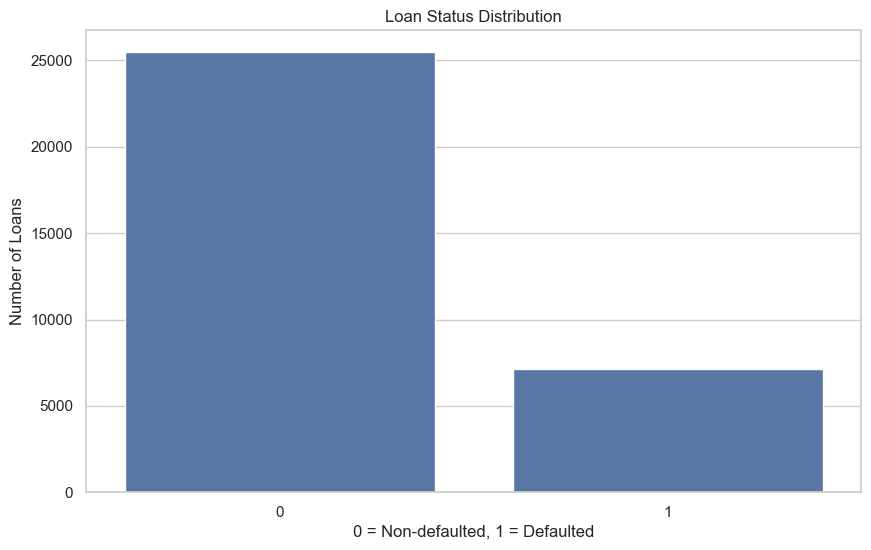

In [7]:
status_counts = df["loan_status"].value_counts().sort_index()
status_pct = df["loan_status"].value_counts(normalize=True).sort_index().mul(100).round(2)
display(status_counts)
display(status_pct)
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.xlabel("0 = Non-defaulted, 1 = Defaulted")
plt.ylabel("Number of Loans")
plt.show()

### 5.2 Home ownership

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

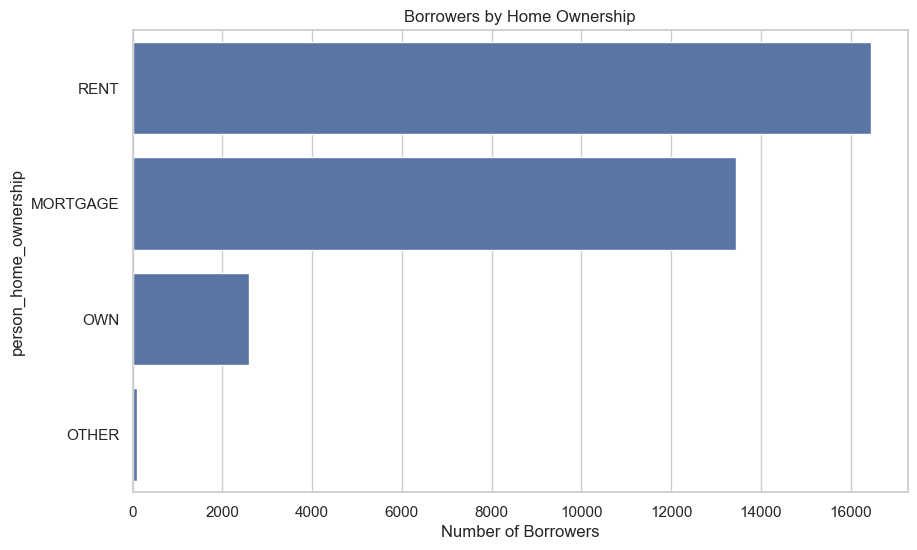

In [8]:
display(df["person_home_ownership"].value_counts())
sns.countplot(data=df, y="person_home_ownership",
              order=df["person_home_ownership"].value_counts().index)
plt.title("Borrowers by Home Ownership")
plt.xlabel("Number of Borrowers")
plt.show()

### 5.3 Loan purpose

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

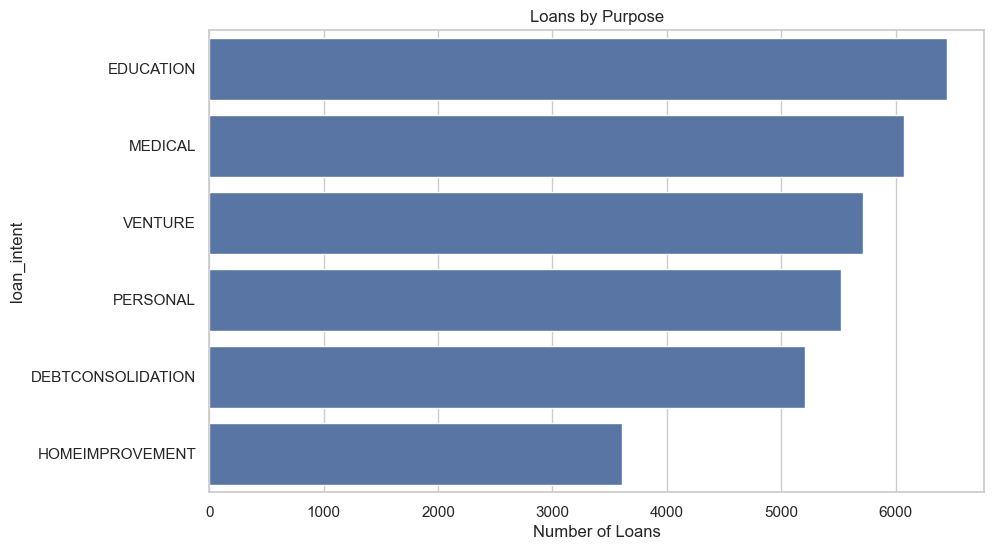

In [9]:
display(df["loan_intent"].value_counts())
sns.countplot(data=df, y="loan_intent",
              order=df["loan_intent"].value_counts().index)
plt.title("Loans by Purpose")
plt.xlabel("Number of Loans")
plt.show()

### 5.4 Loan grade

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

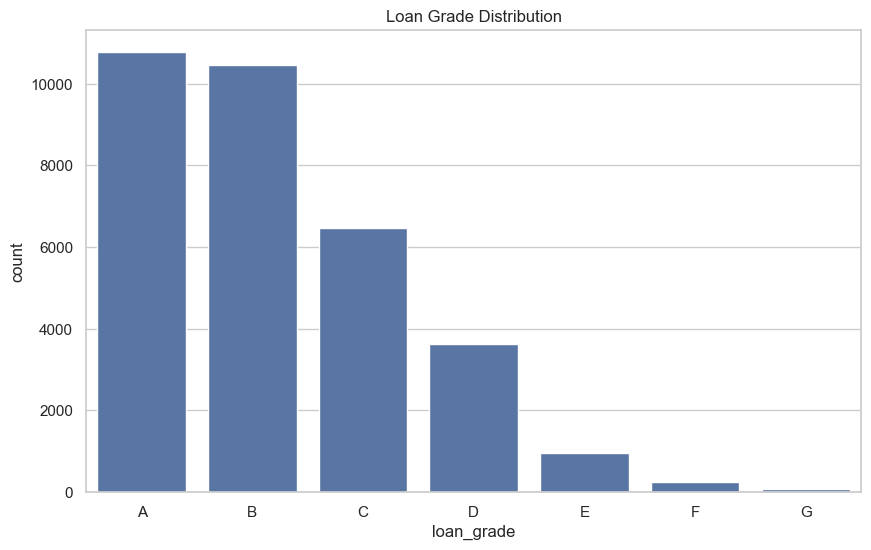

In [10]:
display(df["loan_grade"].value_counts().sort_index())
sns.countplot(data=df, x="loan_grade",
              order=sorted(df["loan_grade"].dropna().unique()))
plt.title("Loan Grade Distribution")
plt.show()

### 5.5 Numerical distributions

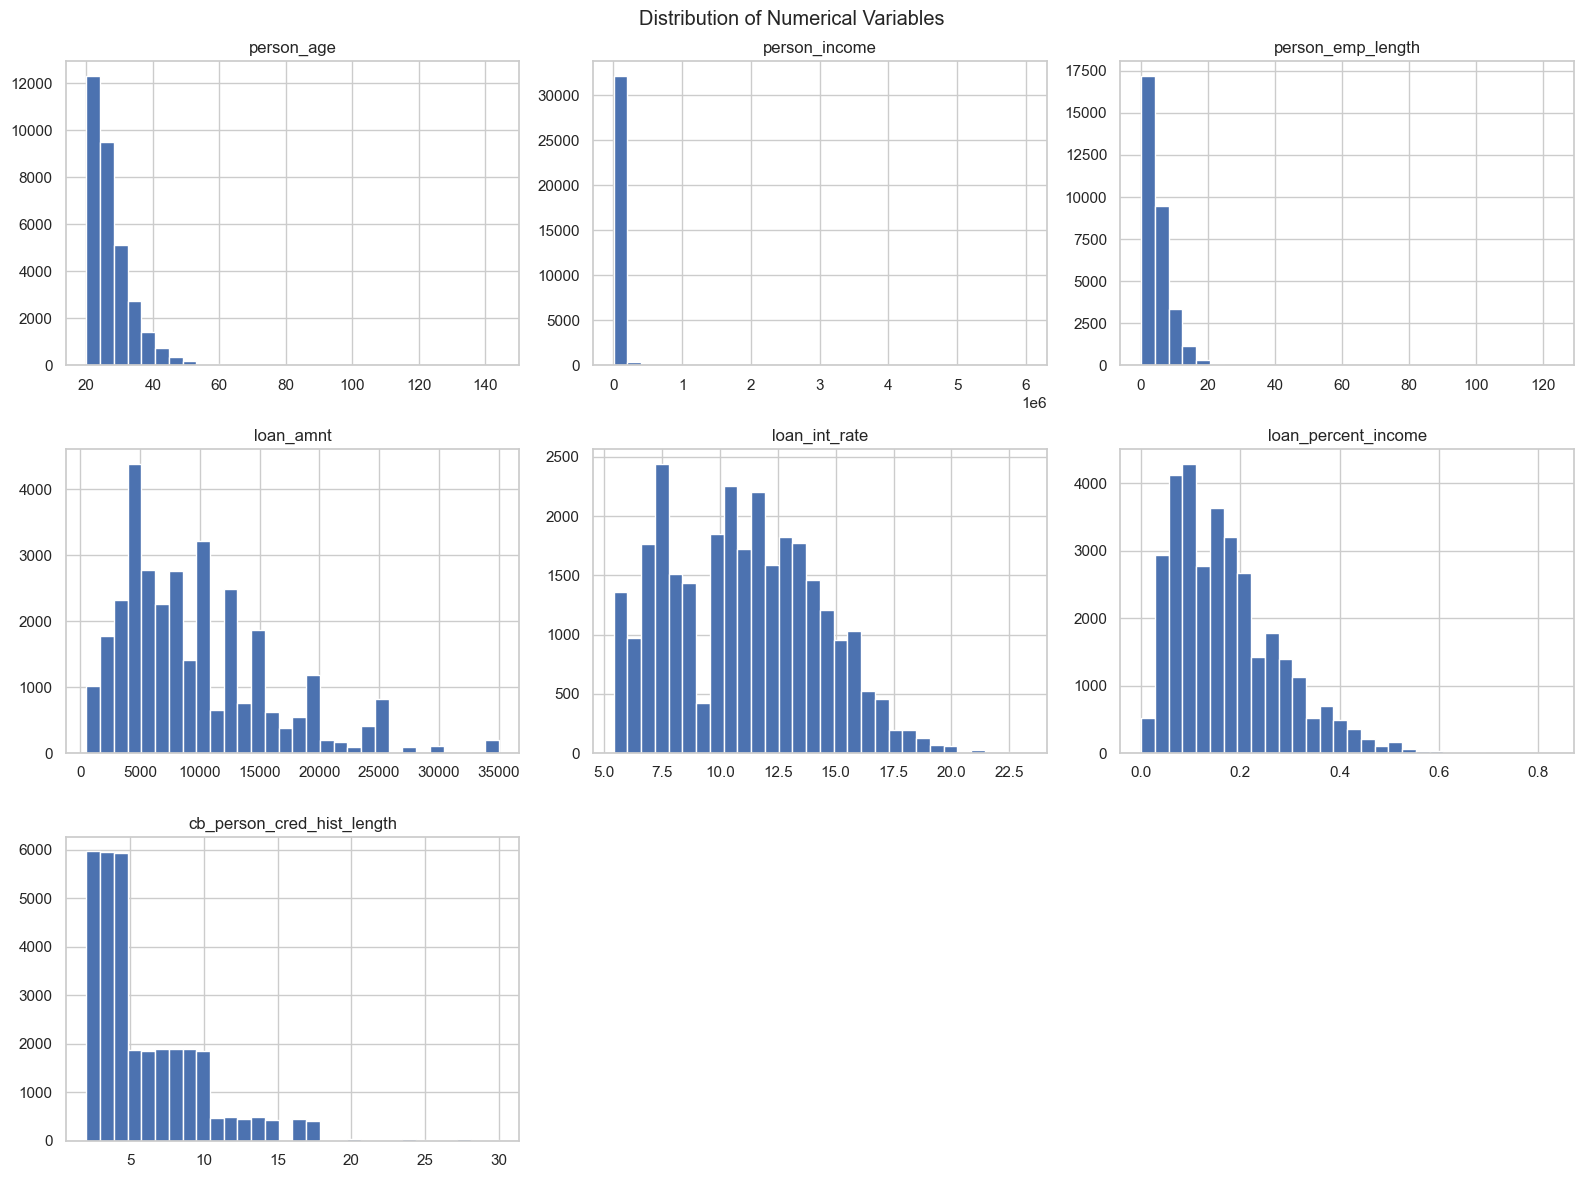

In [11]:
numeric_cols = ["person_age", "person_income", "person_emp_length",
                "loan_amnt", "loan_int_rate", "loan_percent_income",
                "cb_person_cred_hist_length"]
df[numeric_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

## 6. Outlier and invalid-value checks

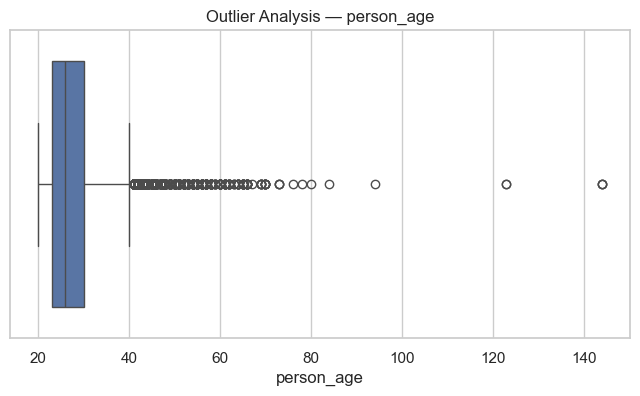

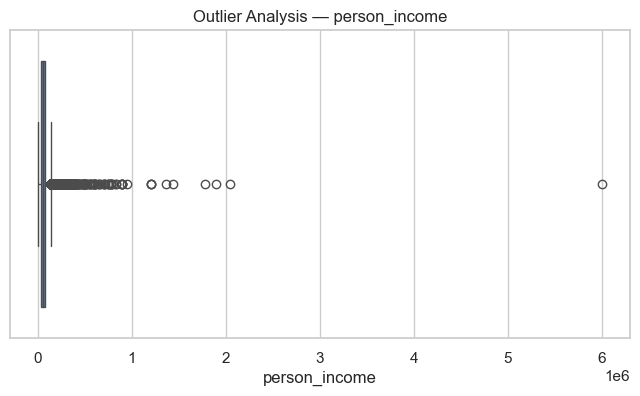

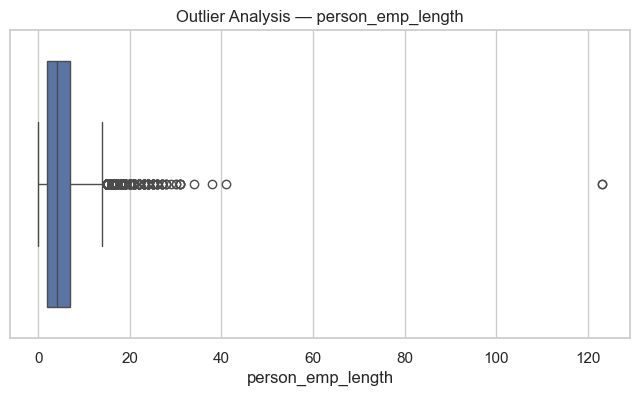

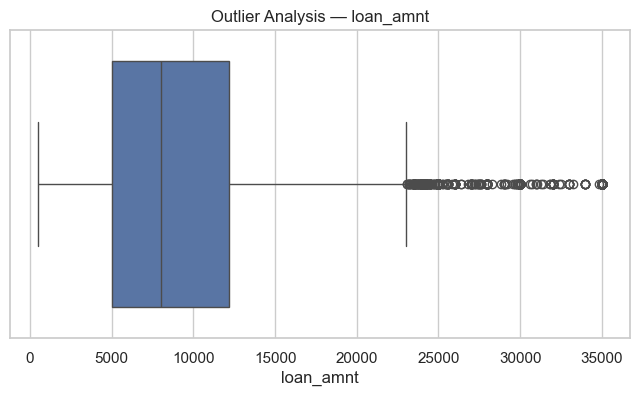

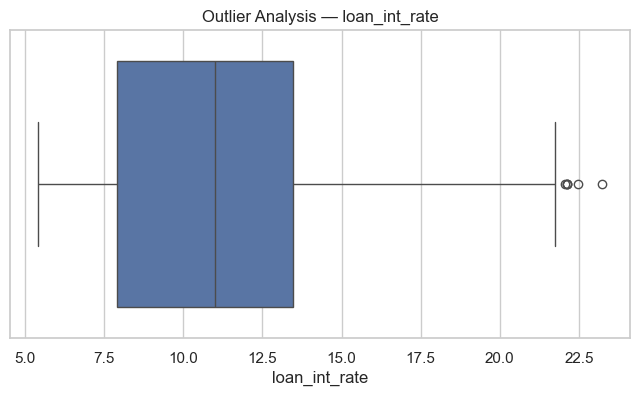

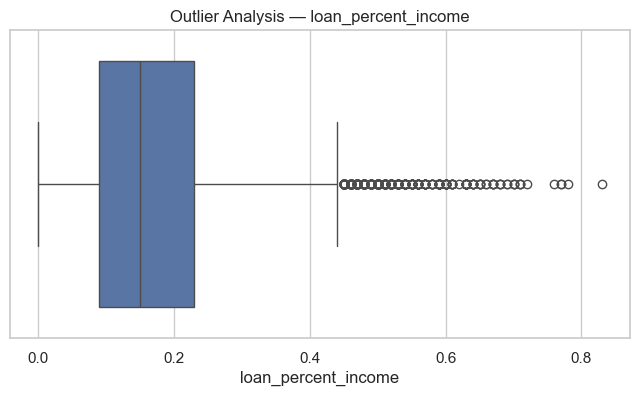

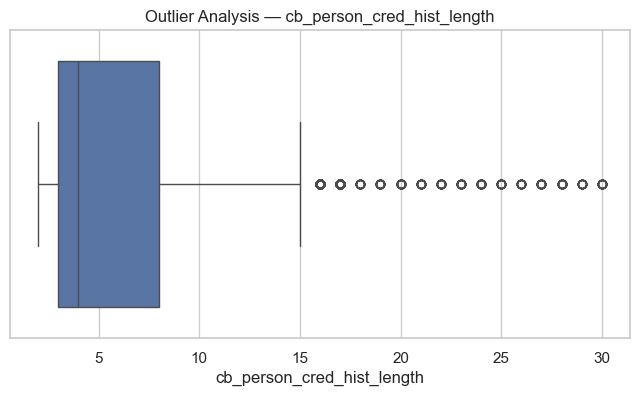

Age below 18: 0
Negative income: 0
Negative employment length: 0
Non-positive loan amount: 0
Invalid loan status: 0


In [12]:
outlier_cols = ["person_age", "person_income", "person_emp_length",
                "loan_amnt", "loan_int_rate", "loan_percent_income",
                "cb_person_cred_hist_length"]
for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Analysis — {col}")
    plt.show()

print("Age below 18:", (df["person_age"] < 18).sum())
print("Negative income:", (df["person_income"] < 0).sum())
print("Negative employment length:", (df["person_emp_length"] < 0).sum())
print("Non-positive loan amount:", (df["loan_amnt"] <= 0).sum())
print("Invalid loan status:", (~df["loan_status"].isin([0, 1])).sum())

Outliers are flags to investigate, not automatic reasons to delete rows.

## 7. Bivariate analysis

### 7.1 Default rate by loan grade

,total_loans,defaulted_loans,average_interest_rate,average_loan_amount,default_rate_pct
loan_grade,,,,,
A,10777,1073,7.327651,8539.273453,9.96
B,10451,1701,10.995555,9995.483686,16.28
C,6458,1339,13.463542,9213.862651,20.73
D,3626,2141,15.361448,10849.241589,59.05
E,964,621,17.009455,12915.845436,64.42
F,241,170,18.609159,14717.323651,70.54
G,64,63,20.251525,17195.703125,98.44


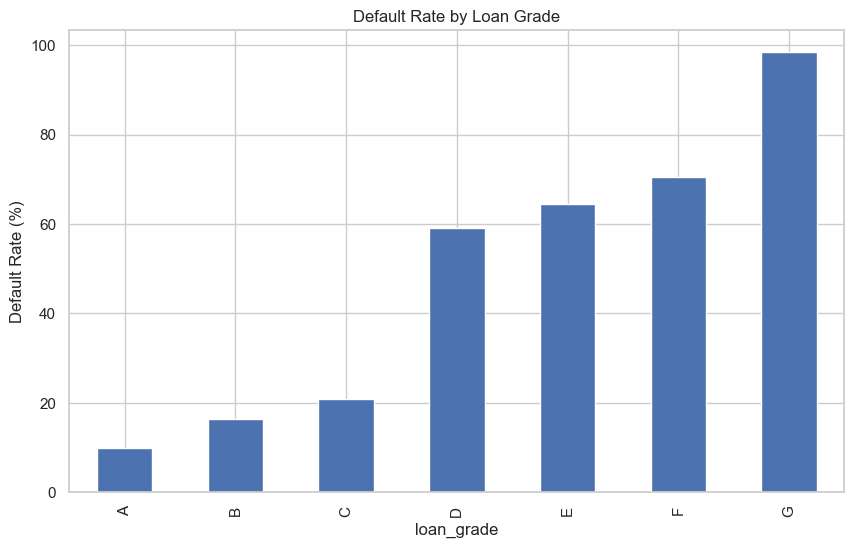

In [13]:
grade_analysis = df.groupby("loan_grade").agg(
    total_loans=("loan_status", "size"),
    defaulted_loans=("loan_status", "sum"),
    average_interest_rate=("loan_int_rate", "mean"),
    average_loan_amount=("loan_amnt", "mean")
)
grade_analysis["default_rate_pct"] = (
    grade_analysis["defaulted_loans"] / grade_analysis["total_loans"] * 100
).round(2)
display(grade_analysis.sort_index())
(df.groupby("loan_grade")["loan_status"].mean().mul(100).sort_index()
 .plot(kind="bar", title="Default Rate by Loan Grade"))
plt.ylabel("Default Rate (%)")
plt.show()

### 7.2 Default rate by loan purpose

,total_loans,defaulted_loans,average_loan_amount,default_rate_pct
loan_intent,,,,
DEBTCONSOLIDATION,5212,1490,9594.886800,28.59
MEDICAL,6071,1621,9259.582441,26.70
HOMEIMPROVEMENT,3605,941,10360.520111,26.10
PERSONAL,5521,1098,9573.772867,19.89
EDUCATION,6453,1111,9482.678599,17.22
VENTURE,5719,847,9583.777758,14.81


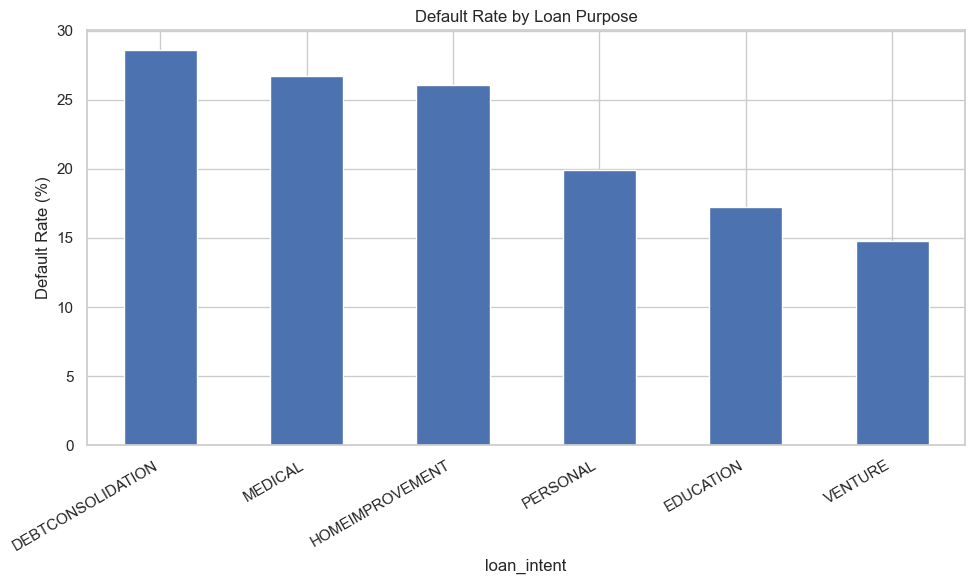

In [14]:
purpose_analysis = df.groupby("loan_intent").agg(
    total_loans=("loan_status", "size"),
    defaulted_loans=("loan_status", "sum"),
    average_loan_amount=("loan_amnt", "mean")
)
purpose_analysis["default_rate_pct"] = (
    purpose_analysis["defaulted_loans"] / purpose_analysis["total_loans"] * 100
).round(2)
display(purpose_analysis.sort_values("default_rate_pct", ascending=False))
(df.groupby("loan_intent")["loan_status"].mean().mul(100)
 .sort_values(ascending=False).plot(kind="bar", title="Default Rate by Loan Purpose"))
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 7.3 Default rate by home ownership

,total_loans,defaulted_loans,average_income,default_rate_pct
person_home_ownership,,,,
RENT,16446,5192,54997.747963,31.57
OTHER,107,33,76387.803738,30.84
MORTGAGE,13444,1690,81127.121690,12.57
OWN,2584,193,57834.812693,7.47


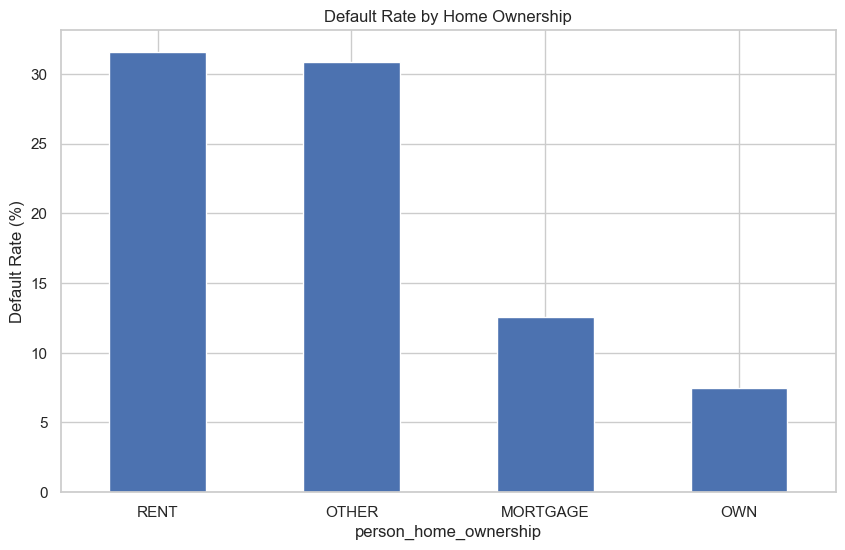

In [15]:
home_analysis = df.groupby("person_home_ownership").agg(
    total_loans=("loan_status", "size"),
    defaulted_loans=("loan_status", "sum"),
    average_income=("person_income", "mean")
)
home_analysis["default_rate_pct"] = (
    home_analysis["defaulted_loans"] / home_analysis["total_loans"] * 100
).round(2)
display(home_analysis.sort_values("default_rate_pct", ascending=False))
(df.groupby("person_home_ownership")["loan_status"].mean().mul(100)
 .sort_values(ascending=False).plot(kind="bar", title="Default Rate by Home Ownership"))
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

### 7.4 Default rate by previous default history

,total_loans,defaulted_loans,default_rate_pct
cb_person_default_on_file,,,
N,26836,4936,18.39
Y,5745,2172,37.81


C:\Users\Rishik Reddy\AppData\Local\Temp\ipykernel_27392\2167631969.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="cb_person_default_on_file", y="loan_status",


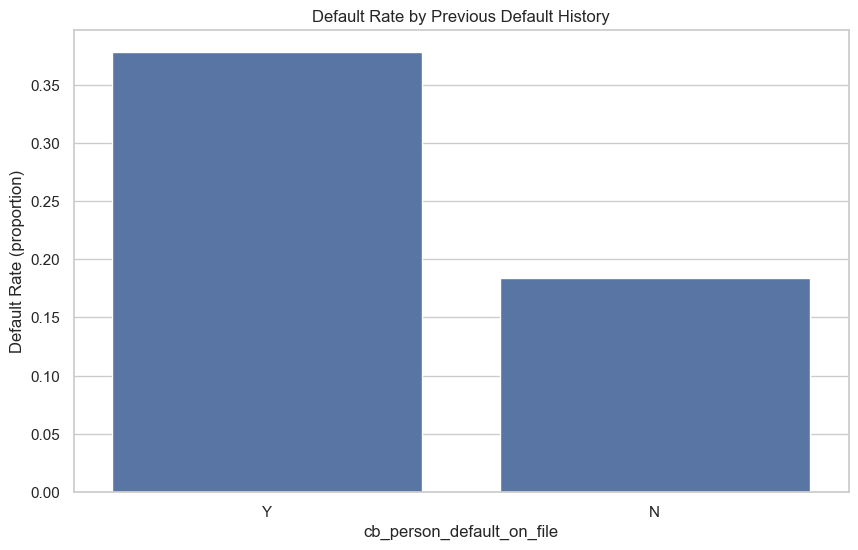

In [16]:
history_analysis = df.groupby("cb_person_default_on_file").agg(
    total_loans=("loan_status", "size"),
    defaulted_loans=("loan_status", "sum")
)
history_analysis["default_rate_pct"] = (
    history_analysis["defaulted_loans"] / history_analysis["total_loans"] * 100
).round(2)
display(history_analysis)
sns.barplot(data=df, x="cb_person_default_on_file", y="loan_status",
            estimator="mean", ci=None)
plt.title("Default Rate by Previous Default History")
plt.ylabel("Default Rate (proportion)")
plt.show()

### 7.5 Interest rate by loan status

,count,mean,median,min,max
loan_status,,,,,
0,23001,10.435999,10.59,5.42,22.06
1,6464,13.060207,13.49,5.42,23.22


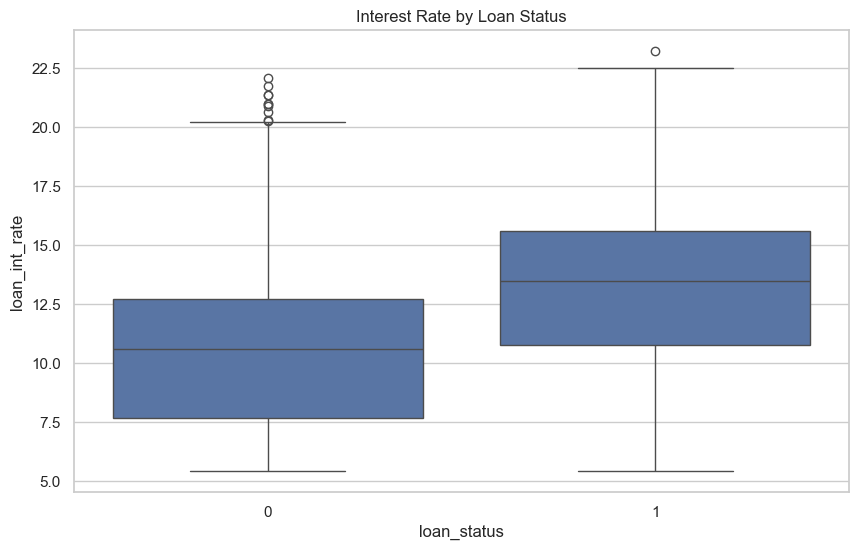

In [17]:
display(df.groupby("loan_status")["loan_int_rate"].agg(["count", "mean", "median", "min", "max"]))
sns.boxplot(data=df, x="loan_status", y="loan_int_rate")
plt.title("Interest Rate by Loan Status")
plt.show()

### 7.6 Loan amount by loan status

,count,mean,median,min,max
loan_status,,,,,
0,25473,9237.464178,8000.0,500,35000
1,7108,10850.502954,9600.0,900,35000


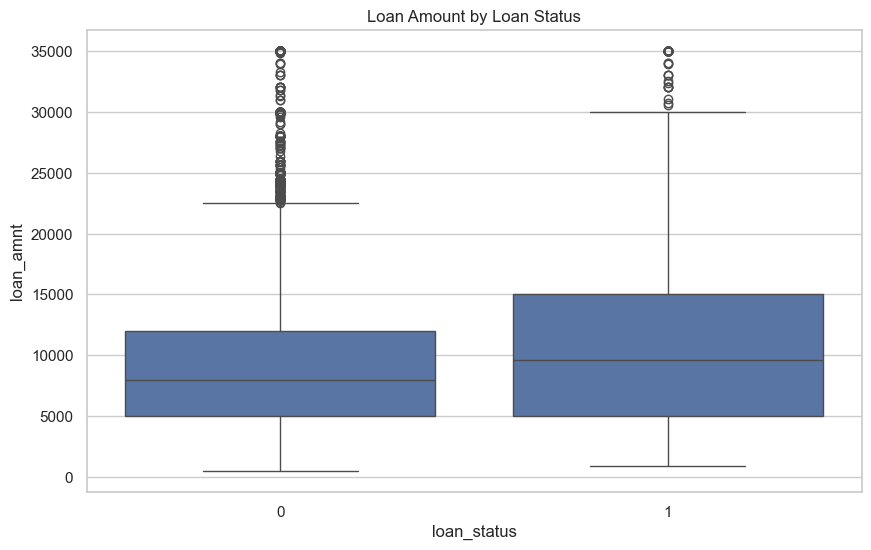

In [18]:
display(df.groupby("loan_status")["loan_amnt"].agg(["count", "mean", "median", "min", "max"]))
sns.boxplot(data=df, x="loan_status", y="loan_amnt")
plt.title("Loan Amount by Loan Status")
plt.show()

### 7.7 Income by loan status

,count,mean,median,min,max
loan_status,,,,,
0,25473,70804.361559,60000.0,7000,6000000
1,7108,49125.652223,41498.0,4000,703800


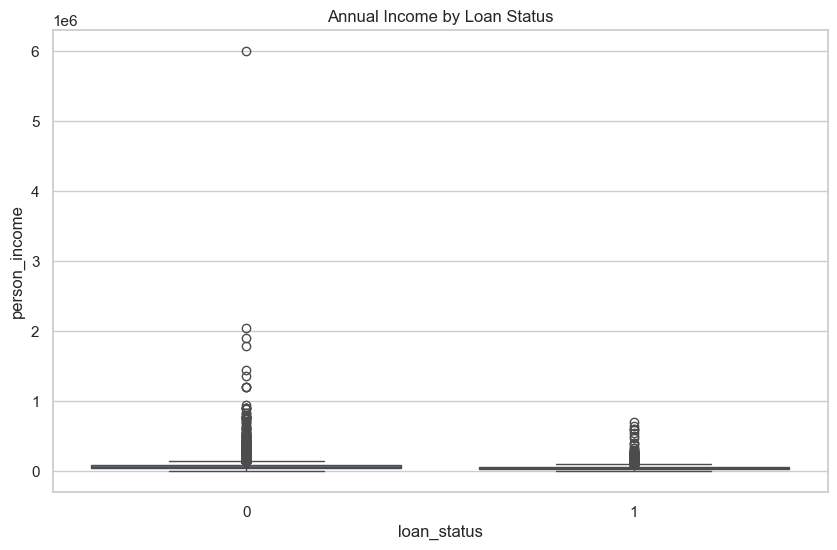

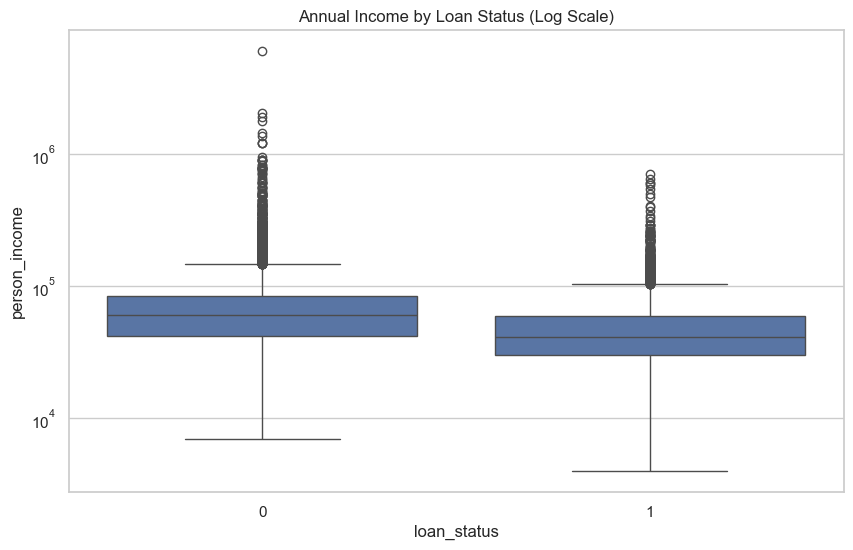

In [19]:
display(df.groupby("loan_status")["person_income"].agg(["count", "mean", "median", "min", "max"]))
sns.boxplot(data=df, x="loan_status", y="person_income")
plt.title("Annual Income by Loan Status")
plt.show()
if (df["person_income"] > 0).all():
    sns.boxplot(data=df, x="loan_status", y="person_income")
    plt.yscale("log")
    plt.title("Annual Income by Loan Status (Log Scale)")
    plt.show()

### 7.8 Loan-to-income ratio by loan status

,count,mean,median
loan_status,,,
0,25473,0.148805,0.13
1,7108,0.246889,0.24


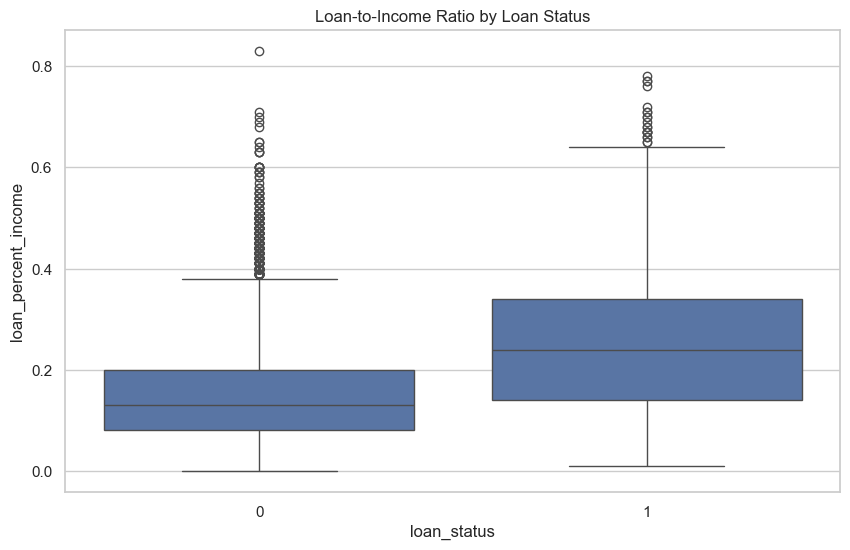

In [20]:
display(df.groupby("loan_status")["loan_percent_income"].agg(["count", "mean", "median"]))
sns.boxplot(data=df, x="loan_status", y="loan_percent_income")
plt.title("Loan-to-Income Ratio by Loan Status")
plt.show()

### 7.9 Credit history length by loan status

,count,mean,median
loan_status,,,
0,25473,5.837475,4.0
1,7108,5.685003,4.0


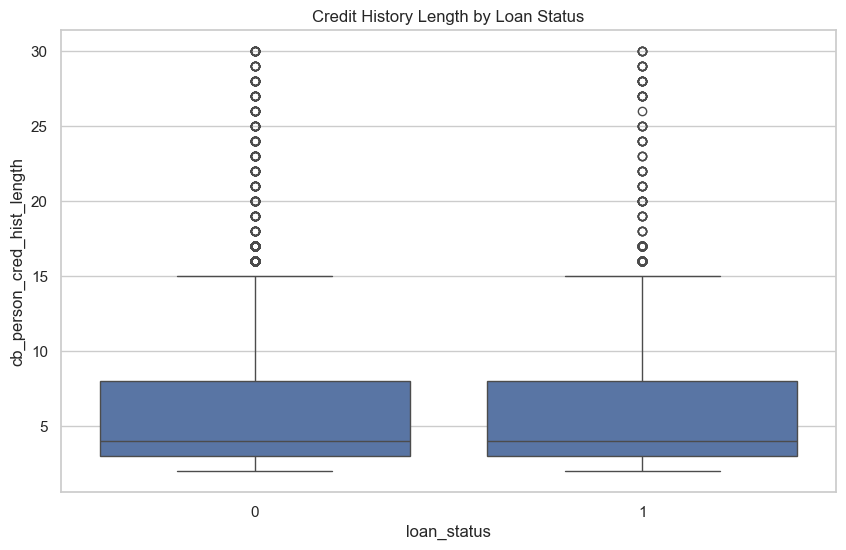

In [21]:
display(df.groupby("loan_status")["cb_person_cred_hist_length"].agg(["count", "mean", "median"]))
sns.boxplot(data=df, x="loan_status", y="cb_person_cred_hist_length")
plt.title("Credit History Length by Loan Status")
plt.show()

### 7.10 Employment length by loan status

,count,mean,median
loan_status,,,
0,24860,4.968745,4.0
1,6826,4.137562,3.0


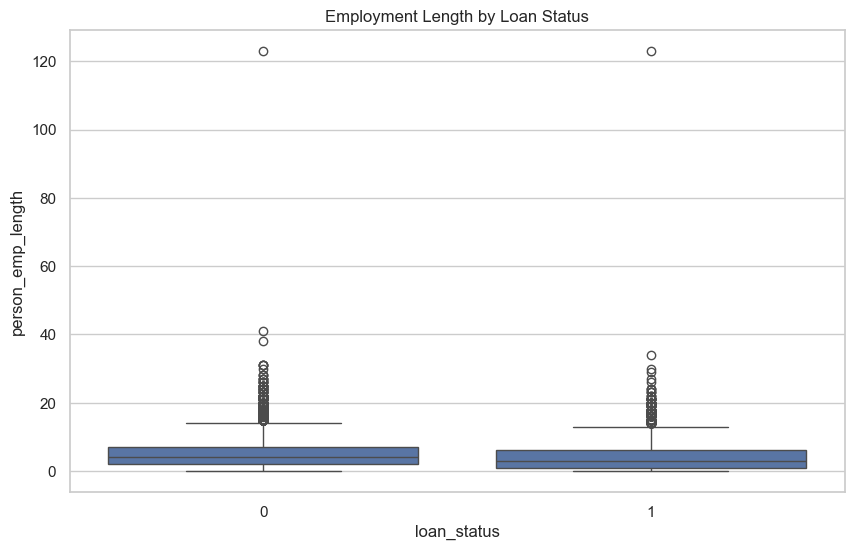

In [22]:
display(df.groupby("loan_status")["person_emp_length"].agg(["count", "mean", "median"]))
sns.boxplot(data=df, x="loan_status", y="person_emp_length")
plt.title("Employment Length by Loan Status")
plt.show()

## 8. Multivariate analysis

### 8.1 Correlation matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.00,0.17,0.16,0.05,0.01,-0.02,-0.04,0.86
person_income,0.17,1.00,0.13,0.27,0.00,-0.14,-0.25,0.12
person_emp_length,0.16,0.13,1.00,0.11,-0.06,-0.08,-0.05,0.14
loan_amnt,0.05,0.27,0.11,1.00,0.15,0.11,0.57,0.04
loan_int_rate,0.01,0.00,-0.06,0.15,1.00,0.34,0.12,0.02
loan_status,-0.02,-0.14,-0.08,0.11,0.34,1.00,0.38,-0.02
loan_percent_income,-0.04,-0.25,-0.05,0.57,0.12,0.38,1.00,-0.03
cb_person_cred_hist_length,0.86,0.12,0.14,0.04,0.02,-0.02,-0.03,1.00


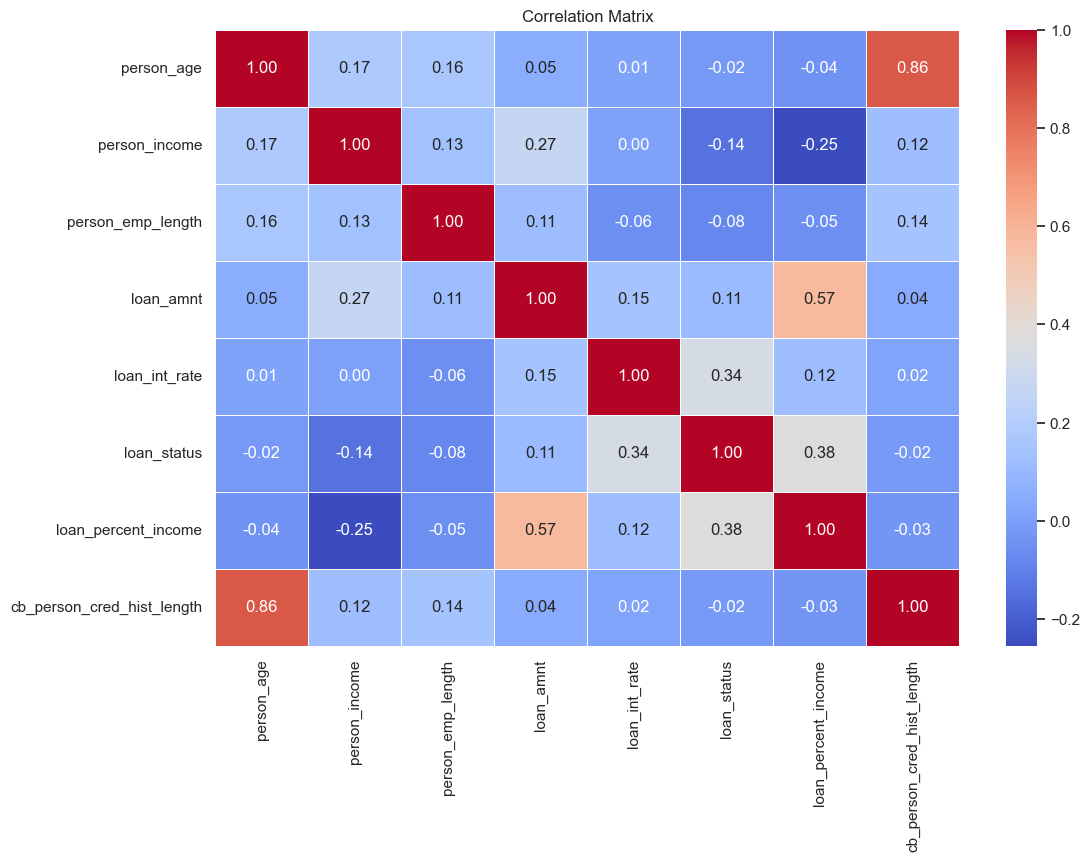

In [23]:
corr_cols = ["person_age", "person_income", "person_emp_length",
              "loan_amnt", "loan_int_rate", "loan_status",
              "loan_percent_income", "cb_person_cred_hist_length"]
corr_matrix = df[corr_cols].corr(numeric_only=True)
display(corr_matrix.round(2))
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### 8.2 Default rate by loan grade and purpose

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
loan_grade,,,,,,
A,11.24,9.29,12.88,11.49,10.59,5.69
B,18.70,15.65,21.52,17.00,18.20,9.09
C,22.74,17.99,27.27,21.04,18.93,19.47
D,92.67,35.31,54.00,87.69,43.55,40.10
E,100.00,43.24,51.75,95.81,48.30,51.69
F,100.00,58.70,65.62,96.15,50.00,36.84
G,100.00,100.00,100.00,100.00,100.00,92.86


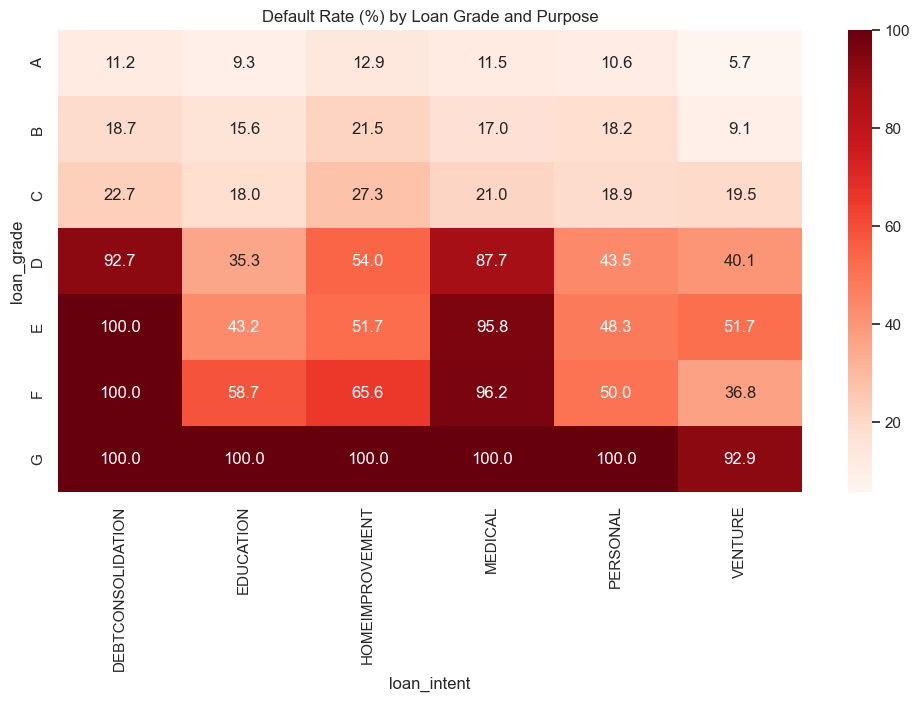

In [24]:
grade_purpose_pivot = df.pivot_table(
    index="loan_grade", columns="loan_intent",
    values="loan_status", aggfunc="mean"
) * 100
display(grade_purpose_pivot.round(2))
plt.figure(figsize=(12, 6))
sns.heatmap(grade_purpose_pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Default Rate (%) by Loan Grade and Purpose")
plt.show()

### 8.3 Default rate by income group

In [25]:
df["income_group"] = pd.qcut(df["person_income"], q=4, duplicates="drop")
income_group_analysis = df.groupby("income_group", observed=True).agg(
    total_loans=("loan_status", "size"),
    defaulted_loans=("loan_status", "sum"),
    average_income=("person_income", "mean")
)
income_group_analysis["default_rate_pct"] = (
    income_group_analysis["defaulted_loans"] / income_group_analysis["total_loans"] * 100
).round(2)
display(income_group_analysis)

,total_loans,defaulted_loans,average_income,default_rate_pct
income_group,,,,
"(3999.999, 38500.0]",8152,3236,28615.324092,39.70
"(38500.0, 55000.0]",8231,1755,47041.932815,21.32
"(55000.0, 79200.0]",8055,1375,66282.422595,17.07
"(79200.0, 6000000.0]",8143,742,122609.044947,9.11


### 8.4 Default rate by loan-to-income group

In [26]:
df["loan_income_group"] = pd.cut(
    df["loan_percent_income"],
    bins=[-np.inf, 0.10, 0.20, 0.30, 0.40, np.inf],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"]
)
loan_income_analysis = df.groupby("loan_income_group", observed=False).agg(
    total_loans=("loan_status", "size"),
    defaulted_loans=("loan_status", "sum")
)
loan_income_analysis["default_rate_pct"] = (
    loan_income_analysis["defaulted_loans"] / loan_income_analysis["total_loans"] * 100
).round(2)
display(loan_income_analysis)

,total_loans,defaulted_loans,default_rate_pct
loan_income_group,,,
0-10%,10484,1229,11.72
10-20%,12066,1823,15.11
20-30%,6197,1360,21.95
30-40%,2714,1865,68.72
40%+,1120,831,74.20


### 8.5 Average loan amount by grade

,average_loan_amount,median_loan_amount,total_loan_amount
loan_grade,,,
A,8539.27,7500.0,92027750
B,9995.48,8400.0,104462800
C,9213.86,8000.0,59503125
D,10849.24,9000.0,39339350
E,12915.85,12000.0,12450875
F,14717.32,15000.0,3546875
G,17195.70,19375.0,1100525


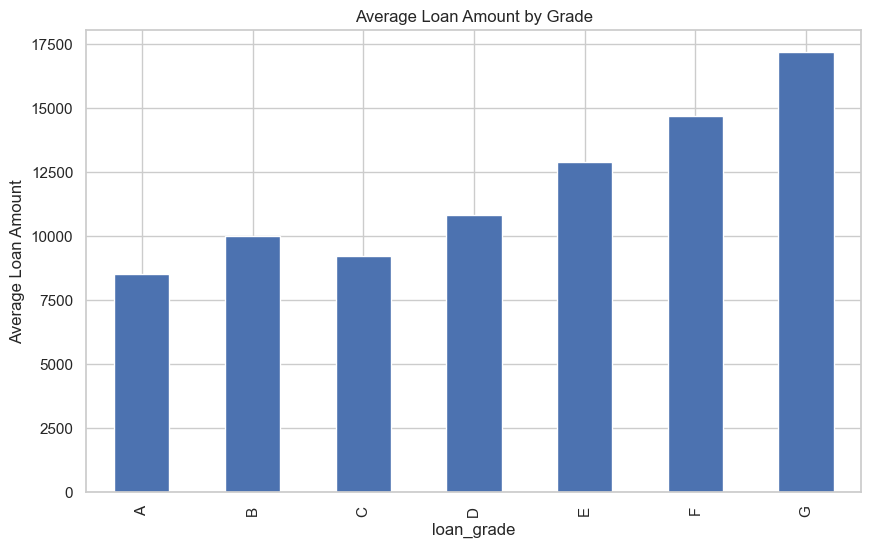

In [27]:
grade_amount = df.groupby("loan_grade").agg(
    average_loan_amount=("loan_amnt", "mean"),
    median_loan_amount=("loan_amnt", "median"),
    total_loan_amount=("loan_amnt", "sum")
).round(2)
display(grade_amount)
grade_amount["average_loan_amount"].plot(kind="bar", title="Average Loan Amount by Grade")
plt.ylabel("Average Loan Amount")
plt.show()

## 9. Overall credit-risk KPIs

In [28]:
total_loans = len(df)
defaulted_loans = (df["loan_status"] == 1).sum()
non_defaulted_loans = (df["loan_status"] == 0).sum()
default_rate = defaulted_loans / total_loans * 100 if total_loans else 0
average_loan_amount = df["loan_amnt"].mean()
total_loan_amount = df["loan_amnt"].sum()
average_interest_rate = df["loan_int_rate"].mean()
average_income = df["person_income"].mean()

print("Total Loans:", total_loans)
print("Defaulted Loans:", defaulted_loans)
print("Non-defaulted Loans:", non_defaulted_loans)
print(f"Default Rate: {default_rate:.2f}%")
print(f"Average Loan Amount: {average_loan_amount:,.2f}")
print(f"Total Loan Amount: {total_loan_amount:,.2f}")
print(f"Average Interest Rate: {average_interest_rate:.2f}%")
print(f"Average Borrower Income: {average_income:,.2f}")

kpi_summary = pd.DataFrame({
    "Metric": ["Total Loans", "Defaulted Loans", "Non-defaulted Loans",
               "Default Rate (%)", "Average Loan Amount", "Total Loan Amount",
               "Average Interest Rate (%)", "Average Borrower Income"],
    "Value": [total_loans, defaulted_loans, non_defaulted_loans,
              round(default_rate, 2), round(average_loan_amount, 2),
              round(total_loan_amount, 2), round(average_interest_rate, 2),
              round(average_income, 2)]
})
display(kpi_summary)

Total Loans: 32581
Defaulted Loans: 7108
Non-defaulted Loans: 25473
Default Rate: 21.82%
Average Loan Amount: 9,589.37
Total Loan Amount: 312,431,300.00
Average Interest Rate: 11.01%
Average Borrower Income: 66,074.85


,Metric,Value
0,Total Loans,3.258100e+04
1,Defaulted Loans,7.108000e+03
2,Non-defaulted Loans,2.547300e+04
3,Default Rate (%),2.182000e+01
4,Average Loan Amount,9.589370e+03
5,Total Loan Amount,3.124313e+08
6,Average Interest Rate (%),1.101000e+01
7,Average Borrower Income,6.607485e+04


## 10. Highest default-rate segments

In [29]:
grade_risk = df.groupby("loan_grade")["loan_status"].agg(["count", "mean"])
grade_risk["default_rate_pct"] = (grade_risk["mean"] * 100).round(2)
print("Default rate by grade:")
display(grade_risk.sort_values("default_rate_pct", ascending=False))

print("Default rate by purpose (%):")
display((df.groupby("loan_intent")["loan_status"].mean() * 100).sort_values(ascending=False).round(2))

print("Default rate by home ownership (%):")
display((df.groupby("person_home_ownership")["loan_status"].mean() * 100).sort_values(ascending=False).round(2))

Default rate by grade:


,count,mean,default_rate_pct
loan_grade,,,
G,64,0.984375,98.44
F,241,0.705394,70.54
E,964,0.644191,64.42
D,3626,0.590458,59.05
C,6458,0.207340,20.73
B,10451,0.162760,16.28
A,10777,0.099564,9.96


Default rate by purpose (%):


loan_intent
DEBTCONSOLIDATION    28.59
MEDICAL              26.70
HOMEIMPROVEMENT      26.10
PERSONAL             19.89
EDUCATION            17.22
VENTURE              14.81
Name: loan_status, dtype: float64

Default rate by home ownership (%):


person_home_ownership
RENT        31.57
OTHER       30.84
MORTGAGE    12.57
OWN          7.47
Name: loan_status, dtype: float64

## 11. Export cleaned dataset and KPI summary

In [37]:
original_columns = [
    "person_age", "person_income", "person_home_ownership",
    "person_emp_length", "loan_intent", "loan_grade", "loan_amnt",
    "loan_int_rate", "loan_status", "loan_percent_income",
    "cb_person_default_on_file", "cb_person_cred_hist_length"
]
cleaned_df = df[original_columns].copy()
cleaned_df.to_csv(r"C:\Users\Rishik Reddy\OneDrive\Desktop\FinTech\Dataset\CleanDataset\credit_risk_dataset_cleaned.csv", index=False)
kpi_summary.to_csv("C:\\Users\\Rishik Reddy\\OneDrive\\Desktop\\FinTech\\Dataset\\CleanDataset\\credit_risk_kpi_summary.csv", index=False)

print("Saved: C:\\Users\\Rishik Reddy\\OneDrive\\Desktop\\FinTech\\Dataset\\CleanDataset\\credit_risk_dataset_cleaned.csv")
print("Saved: C:\\Users\\Rishik Reddy\\OneDrive\\Desktop\\FinTech\\Dataset\\CleanDataset\\credit_risk_kpi_summary.csv")
print("Cleaned data shape:", cleaned_df.shape)
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

Saved: C:\Users\Rishik Reddy\OneDrive\Desktop\FinTech\Dataset\CleanDataset\credit_risk_dataset_cleaned.csv
Saved: C:\Users\Rishik Reddy\OneDrive\Desktop\FinTech\Dataset\CleanDataset\credit_risk_kpi_summary.csv
Cleaned data shape: (32581, 12)
Missing values: 3116
Duplicate rows: 165
